# Principal Component Analysis (PCA)

---

## Intuition

When features are correlated, the data does not actually occupy the full $d$-dimensional space. it lies near a lower-dimensional subspace. **PCA** finds the directions (principal components) that capture the most variance in the data, then projects the data onto those directions.

Think of it as rotating your coordinate system so that the new axes align with the directions of greatest spread in the data.

---

## Algorithm Steps

1. **Center the data:** $\tilde{X} = X - \bar{X}$ (subtract the column means)

2. **Compute the covariance matrix:** $C = \dfrac{1}{n} \tilde{X}^\top \tilde{X} \in \mathbb{R}^{d \times d}$

3. **Eigendecomposition:** $C = V \Lambda V^\top$ where columns of $V$ are eigenvectors and $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_d)$

4. **Sort** eigenvectors by descending eigenvalue $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_d$

5. **Project:** $X_{\text{reduced}} = \tilde{X} V_k$ where $V_k$ contains the top $k$ eigenvectors

**Explained variance ratio** of component $i$: $r_i = \dfrac{\lambda_i}{\sum_j \lambda_j}$

**Connection to SVD:** The eigenvectors of $C$ equal the right singular vectors of $\tilde{X}$: $\tilde{X} = U \Sigma V^\top$

---

## Advantages and Disadvantages

| | |
|---|---|
| **Advantages** | Removes correlated features; reduces noise; speeds up downstream models; enables visualization |
| **Disadvantages** | Principal components lose interpretability; linear only (use kernel PCA for nonlinear); sensitive to feature scaling |

---

## Solutions to Common Problems

- **Scaling:** always apply `StandardScaler` before PCA so no single feature dominates due to larger units
- **Choosing $k$:** use the scree plot (look for the elbow) or pick $k$ such that cumulative explained variance exceeds 90%
- **Nonlinear structure:** use kernel PCA or UMAP instead

---

## Summary Table

| Property | Value |
|---|---|
| Type | Unsupervised dimensionality reduction |
| Key parameters | $k$ (number of components) |
| Objective | Maximize variance in reduced space |
| Requires centering | Yes |
| Requires scaling | Yes (use StandardScaler) |
| Handles nonlinear structure | No (use kernel PCA) |
| Output interpretability | Low (components are linear combinations) |
| Computational cost | $O(d^3)$ for eigendecomposition |

---

**Dataset:** Gym Members Exercise Tracking (or Iris)  
**Task:** Reduce dimensions, visualize clusters, build a scree plot.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.unsupervised_learning import PCA
from rice_ml.preprocess import StandardScaler

In [2]:
try:
    df = pd.read_csv('../../../data/gym_members_exercise_tracking.csv')
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    X = df[num_cols].dropna().values.astype(float)
    labels = None
    print(f'Loaded gym dataset: {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_iris
    iris = load_iris()
    X, labels = iris.data, iris.target
    print('CSV not found. using iris dataset')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Scaled shape: {X_scaled.shape}')

Loaded gym dataset: (973, 13)
Scaled shape: (973, 13)


## Dataset Description

**gym_members_exercise_tracking.csv** contains **973 gym members** with **15 features** covering both demographic and physiological measurements:
[Download from Kaggle](https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset)


- **Demographic:** Age, Gender
- **Body metrics:** Weight (kg), Height (m), BMI, Body Fat Percentage
- **Session data:** Session Duration (hours), Calories Burned, Workout Type
- **Performance:** Max BPM, Avg BPM, Resting BPM
- **Habits:** Water Intake (liters), Workout Frequency (days/week), Experience Level

**Task:** Many of these features are correlated (e.g. Weight and BMI, Calories Burned and Session Duration). PCA will reveal the underlying structure and reduce to 2D for visualization. Ideally, members with similar exercise habits will cluster together in PCA space.

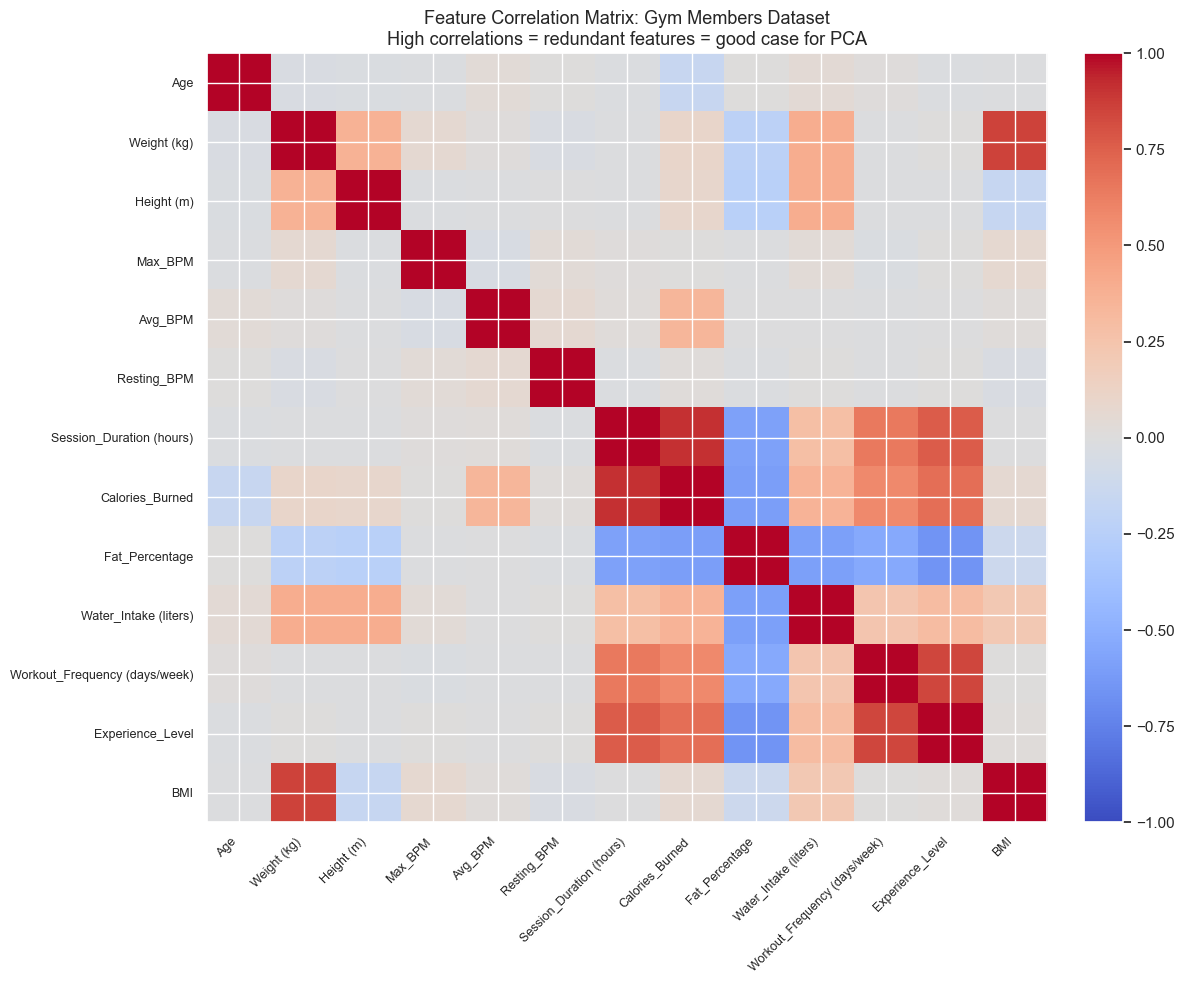

Highly correlated feature pairs (|r| > 0.6):
  Session_Duration (hours) vs Calories_Burned: r = 0.908
  Weight (kg) vs BMI: r = 0.853
  Workout_Frequency (days/week) vs Experience_Level: r = 0.837
  Session_Duration (hours) vs Experience_Level: r = 0.765
  Calories_Burned vs Experience_Level: r = 0.694
  Fat_Percentage vs Experience_Level: r = -0.654
  Session_Duration (hours) vs Workout_Frequency (days/week): r = 0.644


In [3]:
# --- EDA: Correlation heatmap ---
# High correlations between features motivate PCA: correlated features are redundant.
try:
    num_df = df[num_cols].dropna()
    corr = num_df.corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(num_cols)))
    ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(num_cols)))
    ax.set_yticklabels(num_cols, fontsize=9)
    ax.set_title('Feature Correlation Matrix: Gym Members Dataset\nHigh correlations = redundant features = good case for PCA', fontsize=13)
    plt.tight_layout()
    plt.show()
    high_corr = [(num_cols[i], num_cols[j], corr.values[i, j])
                 for i in range(len(num_cols)) for j in range(i+1, len(num_cols))
                 if abs(corr.values[i, j]) > 0.6]
    print('Highly correlated feature pairs (|r| > 0.6):')
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {a} vs {b}: r = {r:.3f}')
except NameError:
    print('Using iris data; building correlation heatmap from scaled X.')
    corr = np.corrcoef(X.T)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_title('Iris Feature Correlation Matrix', fontsize=13)
    plt.tight_layout()
    plt.show()

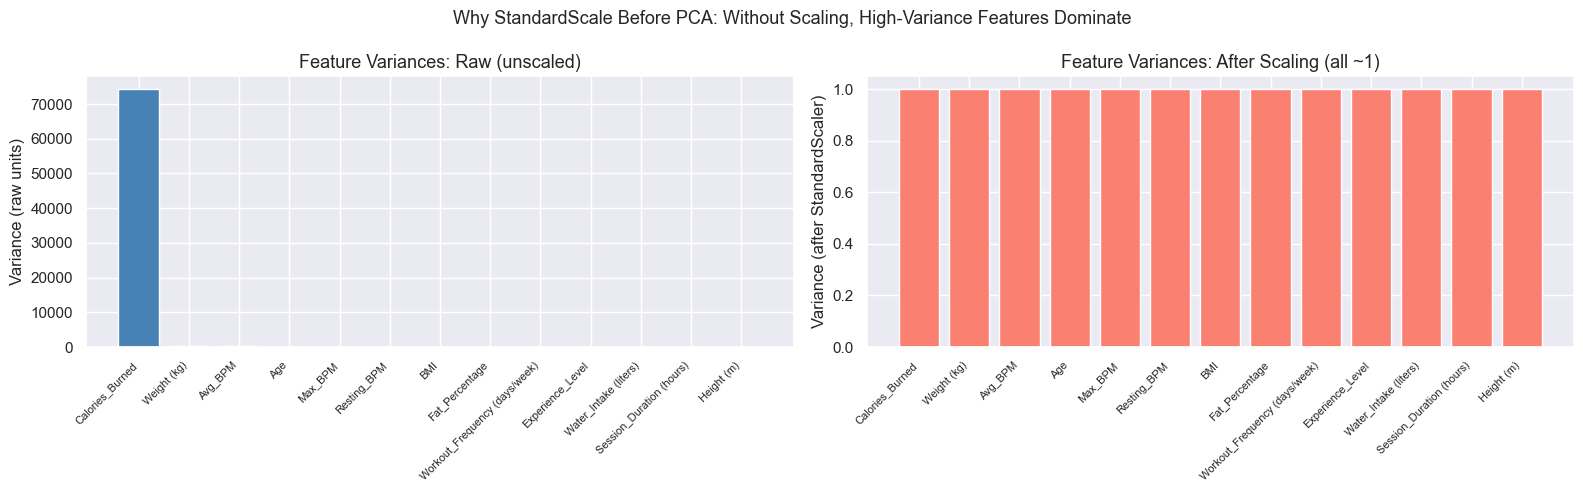

In [4]:
# --- EDA: Feature variance bar chart ---
# Before scaling, some features dominate by sheer magnitude (e.g. Weight in kg vs Age in years).
# This shows WHY we must StandardScale before PCA.
raw_variances = X.var(axis=0)
sorted_idx = np.argsort(raw_variances)[::-1]

try:
    feat_names = [num_cols[i] for i in sorted_idx]
except NameError:
    feat_names = [f'Feature {i}' for i in sorted_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(raw_variances)), raw_variances[sorted_idx], color='steelblue')
axes[0].set_xticks(range(len(feat_names)))
axes[0].set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Variance (raw units)', fontsize=12)
axes[0].set_title('Feature Variances: Raw (unscaled)', fontsize=13)

scaled_variances = X_scaled.var(axis=0)
axes[1].bar(range(len(scaled_variances)), np.sort(scaled_variances)[::-1], color='salmon')
axes[1].set_xticks(range(len(feat_names)))
axes[1].set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Variance (after StandardScaler)', fontsize=12)
axes[1].set_title('Feature Variances: After Scaling (all ~1)', fontsize=13)

plt.suptitle('Why StandardScale Before PCA: Without Scaling, High-Variance Features Dominate', fontsize=13)
plt.tight_layout()
plt.show()

## PCA Geometry: Illustrated

PCA finds the direction of maximum variance (PC1), then the direction of maximum remaining variance orthogonal to PC1 (PC2), and so on. Below is a geometric illustration with 2D correlated data.

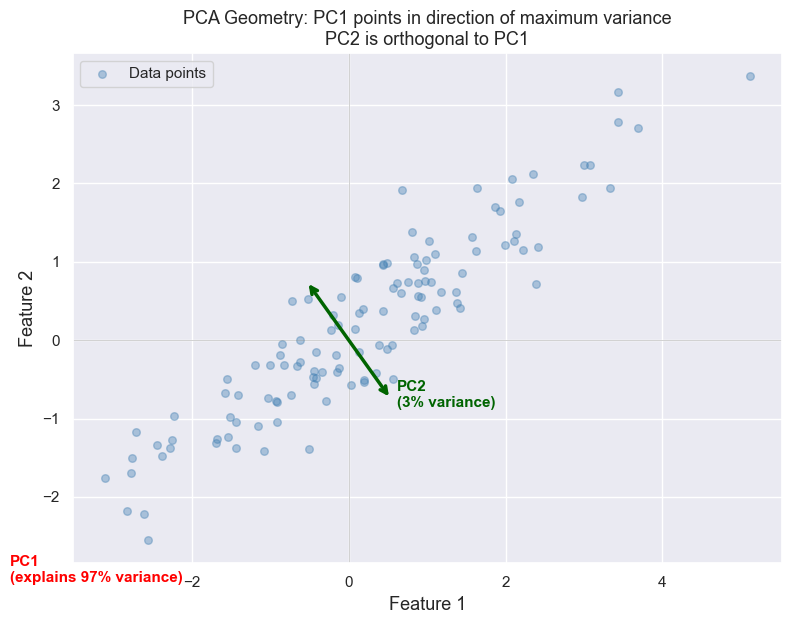

In [5]:
# --- Diagram: PCA geometry with correlated 2D data ---
rng_d = np.random.default_rng(0)
cov_toy = [[2.5, 1.8], [1.8, 1.5]]
X_toy = rng_d.multivariate_normal([0, 0], cov_toy, 120)

# Compute actual principal components
X_toy_c = X_toy - X_toy.mean(axis=0)
C_toy = (X_toy_c.T @ X_toy_c) / len(X_toy_c)
eigvals, eigvecs = np.linalg.eigh(C_toy)
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X_toy[:, 0], X_toy[:, 1], alpha=0.4, color='steelblue', s=30, label='Data points')

# Draw PC1 arrow (scaled by sqrt of eigenvalue = std along that direction)
scale1 = np.sqrt(eigvals[0]) * 2.5
scale2 = np.sqrt(eigvals[1]) * 2.5
pc1 = eigvecs[:, 0] * scale1
pc2 = eigvecs[:, 1] * scale2

ax.annotate('', xy=pc1, xytext=-pc1,
            arrowprops=dict(arrowstyle='<->', color='red', lw=2.5))
ax.text(pc1[0]*1.1, pc1[1]*1.1,
        f'PC1\n(explains {eigvals[0]/eigvals.sum()*100:.0f}% variance)',
        color='red', fontsize=11, fontweight='bold')

ax.annotate('', xy=pc2, xytext=-pc2,
            arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2.5))
ax.text(pc2[0]*1.15, pc2[1]*1.15,
        f'PC2\n({eigvals[1]/eigvals.sum()*100:.0f}% variance)',
        color='darkgreen', fontsize=11, fontweight='bold')

ax.set_xlabel('Feature 1', fontsize=13)
ax.set_ylabel('Feature 2', fontsize=13)
ax.set_title('PCA Geometry: PC1 points in direction of maximum variance\nPC2 is orthogonal to PC1', fontsize=13)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_aspect('equal')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Scree Plot

A scree plot shows how much variance each principal component explains. We look for the "elbow" to choose $k$.

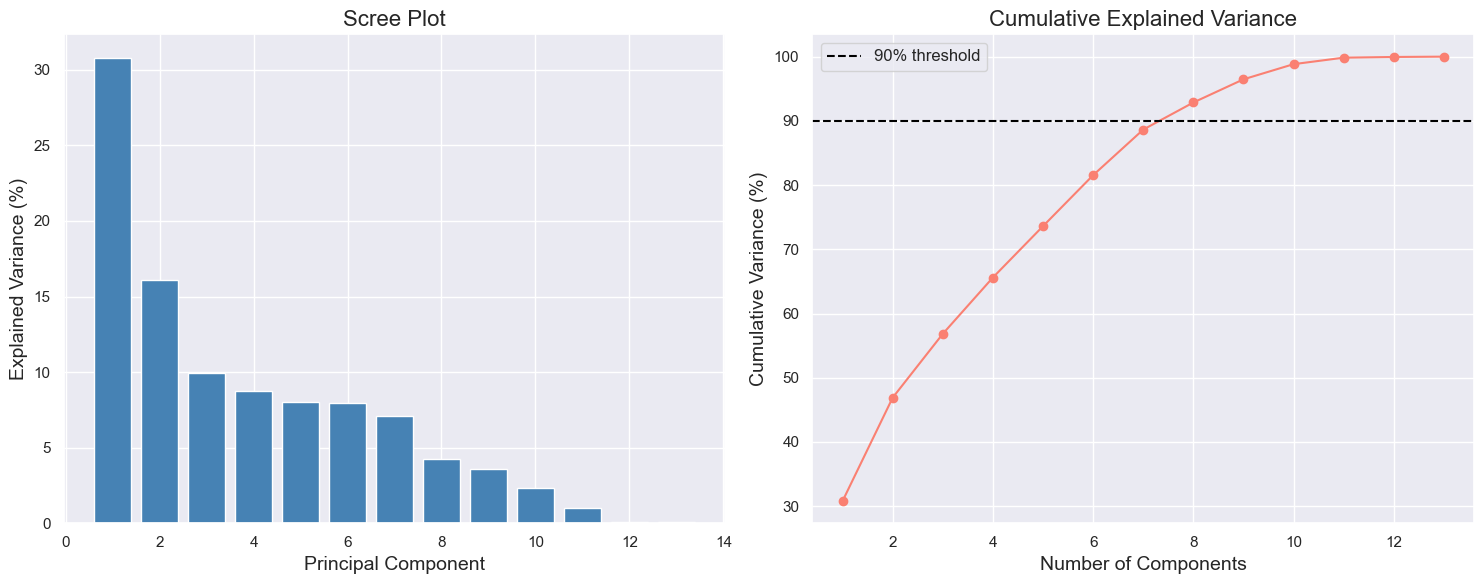

8 components explain >= 90% of variance


In [6]:
pca_full = PCA(n_components=X_scaled.shape[1])
pca_full.fit(X_scaled)

per_var = np.round(pca_full.explained_variance_ratio_ * 100, 2)
cumulative = np.cumsum(per_var)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(range(1, len(per_var) + 1), per_var, color='steelblue')
ax1.set_xlabel('Principal Component', fontsize=14)
ax1.set_ylabel('Explained Variance (%)', fontsize=14)
ax1.set_title('Scree Plot', fontsize=16)

ax2.plot(range(1, len(cumulative) + 1), cumulative, marker='o', color='salmon')
ax2.axhline(90, color='black', linestyle='--', label='90% threshold')
ax2.set_xlabel('Number of Components', fontsize=14)
ax2.set_ylabel('Cumulative Variance (%)', fontsize=14)
ax2.set_title('Cumulative Explained Variance', fontsize=16)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

n_90 = int(np.argmax(cumulative >= 90)) + 1
print(f'{n_90} components explain >= 90% of variance')

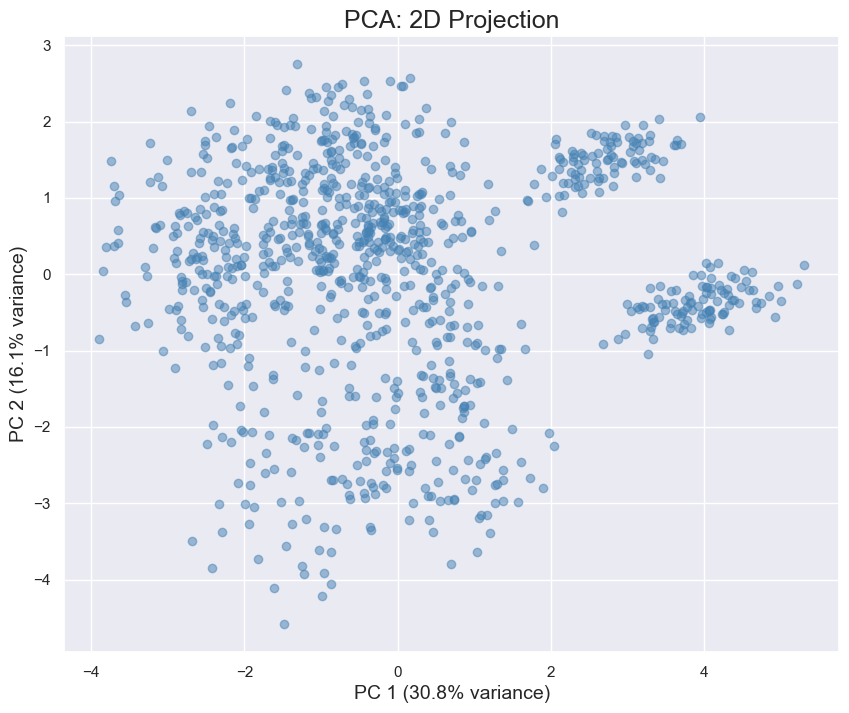

In [7]:
# Project to 2D
pca_2d = PCA(n_components=2)
X_proj = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
if labels is not None:
    for cls, color in zip(np.unique(labels), ['red', 'lightseagreen', 'steelblue']):
        mask = labels == cls
        plt.scatter(X_proj[mask, 0], X_proj[mask, 1], c=color,
                    label=f'Class {cls}', alpha=0.7)
    plt.legend(fontsize=13)
else:
    plt.scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.5, color='steelblue')

plt.xlabel(f'PC 1 ({per_var[0]:.1f}% variance)', fontsize=14)
plt.ylabel(f'PC 2 ({per_var[1]:.1f}% variance)', fontsize=14)
plt.title('PCA: 2D Projection', fontsize=18)
plt.show()

In [8]:
# Reconstruction quality: how much information do we keep with n_90 components?
pca_k = PCA(n_components=min(n_90, X_scaled.shape[1]))
X_reconstructed = pca_k.inverse_transform(pca_k.fit_transform(X_scaled))

reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2)
print(f'Reconstruction MSE with {n_90} components: {reconstruction_error:.4f}')

Reconstruction MSE with 8 components: 0.0714


## Interpretation

- The **scree plot** shows variance captured by each PC. we typically keep enough PCs to explain 90%+ of variance.
- PCA is **unsupervised**: it finds directions of maximum variance without using class labels.
- The correlation heatmap motivates PCA: many gym features are correlated (e.g. Calories Burned with Session Duration, BMI with Weight), so the data is intrinsically lower-dimensional than 15 features suggest.
- The **2D projection** is useful for visualizing high-dimensional data and spotting natural clusters (e.g. by workout type or experience level).
- **Reconstruction MSE** quantifies how much information is lost by keeping only the top $k$ components. a small error with far fewer components confirms the dimensionality reduction is effective.